Note: you may need to restart the kernel to use updated packages.


data size dfinal: 8256
Drawing Data...ctrl-c to quit



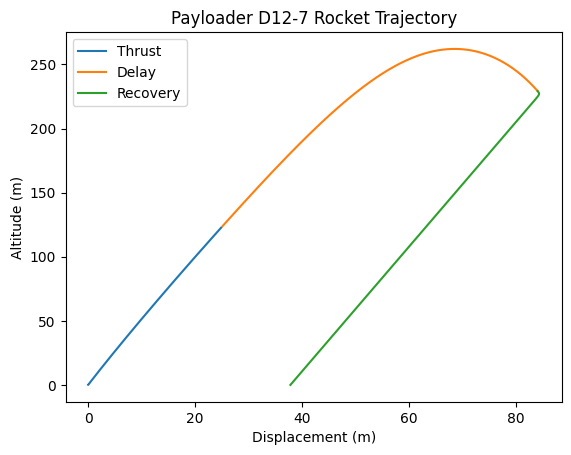

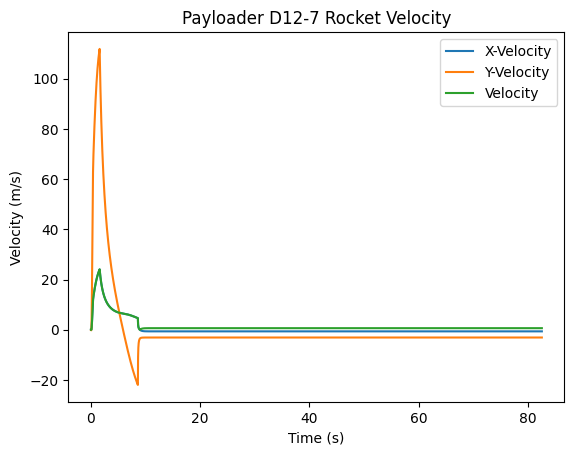

In [2]:
# Установка библиотеки PyRocketSim 
%pip install PyRocketSim

# Импорт библиотеки
import PyRocketSim

# Инициализация переменных:
# dfinal - вектор для хранения итоговых данных полёта
# rp1 - объект, представляющий ракету
# rf1 - объект, представляющий силы, действующие на ракету
dfinal = PyRocketSim.fvec()
rp1 = PyRocketSim.prock()
rf1 = PyRocketSim.frock()

# Настройка параметров моделирования:
tstep = 0.01
delay = 7.0

# Инициализация модели ракеты с использованием файла спецификации двигателя
PyRocketSim.initialize(rp1, rf1, "spec/Arachnid_D12-7.txt")
# Использование кривой тяги из файла
PyRocketSim.use_thrustCurve("spec/Payloader_D12-7.txt")


# Получение времени работы двигателя
btime = PyRocketSim.get_btime()
ind = 0



#--------------Фаза работы двигателя----------------#
for i in range(int(btime/tstep)):
    PyRocketSim.calc_forces(rp1, rf1, (ind * tstep))
    PyRocketSim.calc_kinematics(rp1, tstep)
    PyRocketSim.log_data(rp1, dfinal)
    ind += 1

index1 = ind


#----------------Фаза задержки----------------#
PyRocketSim.set_thrust(0.0)
PyRocketSim.set_stmass(0.0)

for i in range(int(delay/tstep)):
    PyRocketSim.calc_forces(rp1, rf1, 0)
    PyRocketSim.calc_kinematics(rp1, tstep)
    PyRocketSim.log_data(rp1, dfinal)
    ind += 1

index2 = ind

#---------Фаза снижения с парашютом---------------------#

PyRocketSim.deploy_Chute()

#Пока ракета не достигнет земли - продолжаем моделирование
while(rp1.d.y > 0):
    PyRocketSim.calc_forces(rp1, rf1, 0)
    PyRocketSim.calc_kinematics(rp1, tstep)
    PyRocketSim.log_data(rp1, dfinal)

#Если данные собраны, строим графики
# index1 и index2 используются для разметки фаз полёта на графике
print(f"\n\ndata size dfinal: {len(dfinal.v)}\nDrawing Data...ctrl-c to quit\n")
if (len(dfinal.v) > 0):
    PyRocketSim.draw(dfinal, index1, index2)



    